In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                      # run everything from the project root
sys.path.insert(0, os.getcwd())

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
pd.set_option("display.max_columns", 50)

# 04 · K-Means Clustering
Choose *k* with the **Elbow Method** and **Silhouette Score**, train the final model, and save it.

In [2]:
from src import clustering, evaluation
from src.feature_engineering import add_features, get_cluster_matrix

df = pd.read_csv('data/processed/visitors_cleaned.csv')
feats = add_features(df)
X_scaled, scaler = clustering.scale_features(get_cluster_matrix(feats))
results = clustering.evaluate_k_range(X_scaled, range(2, 11))
results.round(3)

,k,inertia,silhouette,davies_bouldin
0,2,63649.923,0.604,0.554
1,3,50597.877,0.401,1.019
2,4,39809.646,0.292,1.138
3,5,32632.385,0.322,1.052
4,6,28021.821,0.333,1.005
5,7,25452.034,0.285,1.088
6,8,23157.066,0.305,1.033
7,9,21318.236,0.316,0.999
8,10,19767.202,0.305,1.023


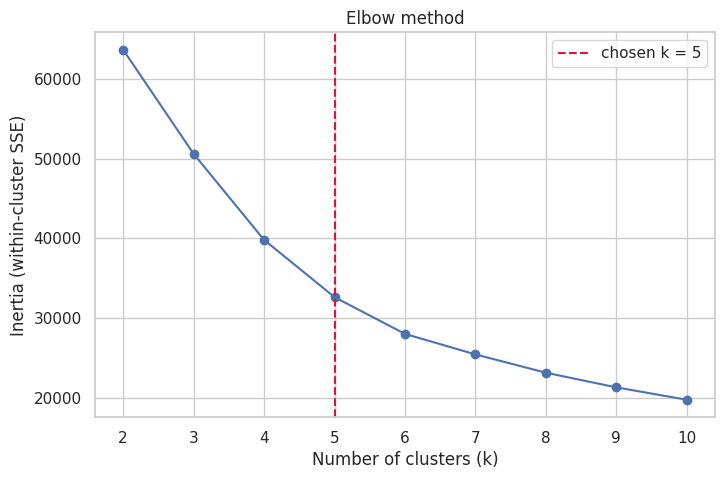

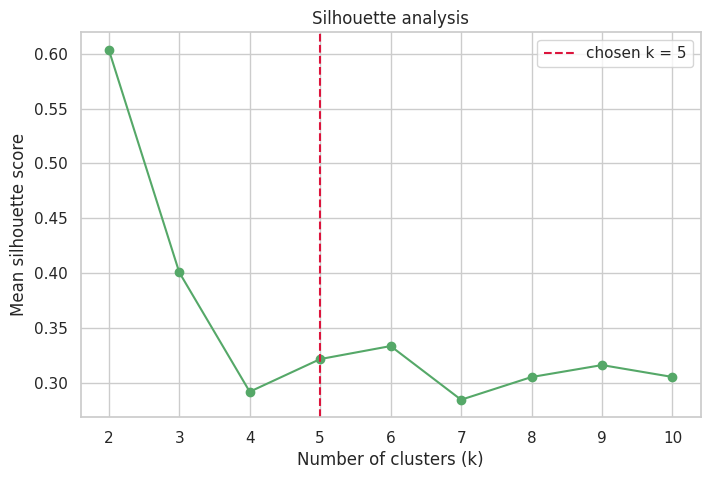

In [3]:
K = 5
evaluation.plot_elbow(results, K); plt.show()
evaluation.plot_silhouette(results, K); plt.show()

### Choosing k
- **k = 2/3** have the best silhouette, but they only separate bouncers / new / returning visitors – too coarse to act on.
- Silhouette has a local peak at **k = 5–6** (0.32 vs 0.33 – practically tied) and the inertia curve bends around 4–6.
- We choose **k = 5**: at the elbow, nearly the best silhouette among useful values, and the fewest segments that still separate *buyers* from *browsers*.

In [4]:
model = clustering.train_kmeans(X_scaled, K)
labels = model.labels_
print(evaluation.cluster_quality(X_scaled, labels))
print(pd.Series(labels).value_counts().sort_index())

{'silhouette': 0.3215848787334956, 'davies_bouldin': 1.0520011375004148, 'calinski_harabasz': 6075.967726895947}
0    2118
1    2743
2    5075
3     648
4    1621
Name: count, dtype: int64


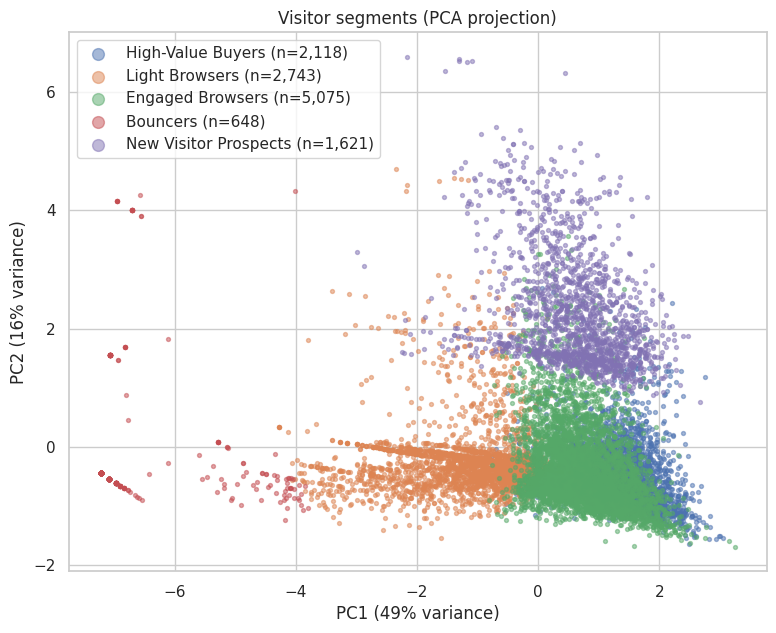

In [5]:
profile = evaluation.profile_clusters(feats, labels)
segment_info = evaluation.name_segments(profile)
evaluation.plot_clusters(X_scaled, labels, segment_info); plt.show()

The 2-D PCA view shows overlap between the browsing-heavy groups – expected, because real visitor behaviour is a continuum rather than isolated blobs.

In [6]:
clustering.save_artifacts(model, scaler, segment_info)
print(sorted(os.listdir('models')))

['kmeans_model.joblib', 'scaler.joblib', 'segment_info.json']
